# Week 3 Activity: Synthesis Functions

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code. For this activity, you may want to consult your Audio Tech I notes (or the Computer Music Tutorial)

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read, write
from IPython.display import Audio
from scipy import signal
fs = 44100  # Global Sampling frequency

## 1. Create an envelope function

Write a function called adsr() that will modify a passed sound according to an ADSR envelope that is user-defined. 
Your function should include the following arguments at a minimum:

1) a: Time to reach maximum amplitude (can be zero to length of input). (float)

2) s: The level (amplitude) of the sustain portion. (float)

3) d: Time to descend from max to sustain level (N.B. time can be zero, and sustain can be False.) (float)

4) r: Time to descend to zero (N.B. should be a minimum of 20ms). (float)

5) x: array of samples of length n that will be modulated by the envelope. (np.array)

Your function should return the input sound modified by the envelope

**Notes**

Optimizing your function:  The following are things to consider, but not necessary as a "first step":  

* Your function ideally should allow for all scenarios including passing sound arrays of various lengths, and, it should allow for a sharp attack followed by an immediate decay with zero sustain (like a plucked or percussive sound) regardless of the total length of the sound passed. I.e., If there is no sustain value, then the Decay (#3) and Sustain (#2) are moot, so your function should just ascend to peak value over some time, x, and then descend to zero over time x.

* Be sure to include default values to all your arguments (except #5)

* You will need to define additional defaults within the function such as the sample rate. (You may want to make this an argument variable with a default value).


Heads up: This will likely be the most tedious question of this activity as it is a lot of array manipulation and edge case finding. 

Note: depending on your implementation, the following functions may come in handy:

`np.max` returns the maximum value in an array  
`np.min` returns the minimum value in an array  
`np.size` returns the total length of an array   
`np.where` returns index value(s) matching boolean conditions  
`np.zeros(n)` returns an array of zeros of length n  
`np.ones(n)` returns an array of ones of length n  
`np.full(n, val)` returns an array of values (val) of length n  

In [445]:
def adsr(x, a_time=None, s_lvl=None, d_time=None, r_time=None, fs=44100):
    t = len(x)/fs

    if a_time is None:
        a_time = (1/5 * t)
        print("Attack time not specified. a_time set to default of 1/5 of audio length.")

    if d_time is None:
        d_time = (1/5 * t)
        if s_lvl != None:
            print("Decay time not specified. d_time set to default of 1/5 of audio length.")

    if r_time is None:
        r_time = (1/5 * t)
        print("Release time not specified. r_time set to default of 1/5 of audio length.")
    elif r_time < 0.02 and not (t-0.02 <= a_time <= t):
        r_time = 0.02
        print("Release time must be at least 20ms. r_time set to 20ms.")
    elif (t-0.02 <= a_time <= t):
        r_time = t - a_time
        print("Attack time goes to within 20ms of end of audio signal. Release time set to amount of remaining ms, or: ", r_time)

    if a_time + d_time + r_time > t:
        a_time = (1/5 * t)
        d_time = (1/5 * t)
        r_time = (1/5 * t)
        print("Attack, decay and release time combine to a duration longer than input audio. Please input smaller values. Values set to defaults (each 1/5 of audio length).")

    if s_lvl is None: 
        a_samp = int(a_time * fs)
        d_samp = 0
        r_samp = int(r_time * fs)
        s_samp = 0
        zero_arr = np.zeros((len(x) - a_samp - d_samp - r_samp))
        zero_samp =len(zero_arr)
        env_samp = a_samp + d_samp + r_samp + s_samp + zero_samp #for error handling only
        print("No sustain input. Sustain and decay parameters nullified, only attack and release applied. Amplitude of 0 applied to remainder of audio.")
    else: 
        a_samp = int(a_time * fs)
        d_samp = int(d_time * fs)
        r_samp = int(r_time * fs)
        s_samp = int(len(x) - a_samp - d_samp - r_samp)
        zero_arr = []
        zero_samp = len(zero_arr)
        env_samp = a_samp + d_samp + r_samp + s_samp + zero_samp #for error handling only

    if env_samp != len(x) and s_lvl is None:
       zero_arr = np.zeros(len(x) - a_samp - d_samp - r_samp + (len(x) - env_samp))
       zero_samp = len(zero_arr)
       env_samp = a_samp + d_samp + r_samp + s_samp + zero_samp
    else: 
       s_samp = s_samp + (len(x) - env_samp)
       env_samp = a_samp + d_samp + r_samp + s_samp + zero_samp
    #Compensates envelope length in case of length inconsistency in envelope array and original audio array caused by truncation by the int function.

    if s_lvl is None:
        a = np.linspace(0, 1, a_samp)
        r = np.linspace(1, 0, r_samp)
        z = np.full(len(zero_arr), 0)
        env = np.concatenate([a,r,z])
    else: 
        a = np.linspace(0, 1, a_samp)
        d = np.linspace(1, s_lvl, d_samp)
        s = np.full(s_samp, s_lvl)
        r = np.linspace(s_lvl, 0, r_samp)
        env = np.concatenate([a,d,s,r])

    out = env * x
    
    return out


In [448]:
# AUDIO TEST CASE:

(fs, sine_env) = read("../audio/sine-440.wav")

(fs, drums) = read("../audio/80spopDrums.wav")

y = adsr(drums, a_time=None, s_lvl=None, d_time=None, r_time=None, fs=fs)

Audio(y, rate=fs)

Attack time not specified. a_time set to default of 1/5 of audio length.
Release time not specified. r_time set to default of 1/5 of audio length.
No sustain input. Sustain and decay parameters nullified, only attack and release applied. Amplitude of 0 applied to remainder of audio.


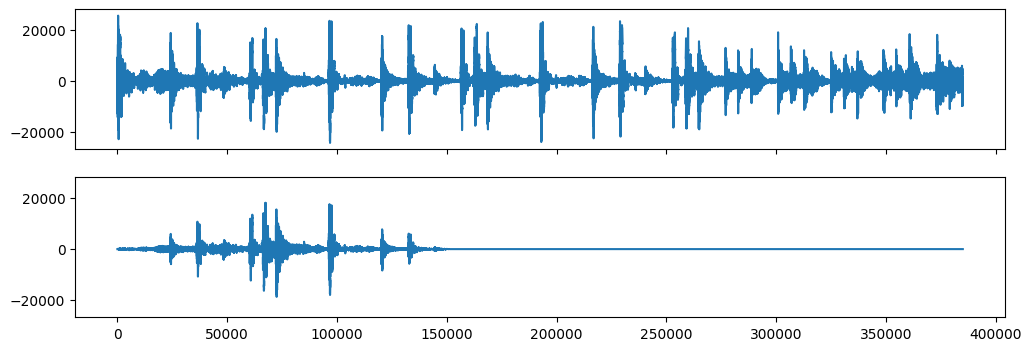

In [449]:
# GRAPHING TEST CASE:

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True)

ax1.plot(drums)
ax2.plot(y)

## 2. Create an amplitude modulation function

1. Write a function called amp_mod() for amplitude modulation. Your function should have the following arguments at minimum.

* carrier input signal (np.array)
* sampling rate (float)
* frequency of modulator (float)
* wave shape of the modulator (string: 'sine', 'square', 'tri', 'saw')
* boolean for polarity - should it be bipolar (True or False)

You need sampling rate to determine the proper relationship to length of the array and frequency.

Note: 
* modulator wave_shape --> should be sinusoid, square, sawtooth, or triangle (you may use `scipy.signal` library to make it easier - see: https://docs.scipy.org/doc/scipy/reference/signal.html and scroll to "Waveforms")  
* time --> the time or length of the carrier signal (modulator should exactly match)


In [283]:

def amp_mod(carrier, fs=44100, mod_freq=None, mod_index=None, wav_shape=None, polarity=False):
    t = np.arange(len(carrier)) / fs

    #if carrier.dtype == np.int16:
       # carrier = carrier.astype(np.float32) / 32768.0
    #elif carrier.dtype == np.int32:
     #   carrier = carrier.astype(np.float32) / 2147483648.0
   #else:
       # carrier = carrier.astype(np.float32)

    
    if mod_freq is None:
        mod_freq = 10
        print("Modulation frequency not specified. mod_freq set to default of 10 Hz.")

    if mod_index is None:
        mod_index = 1
        print("Modulation index not specified. mod_index set to default of 1.")

    if wav_shape == 'sine' or wav_shape == 'sin' or wav_shape == None:
        modulator = mod_index * np.sin(2 * np.pi * mod_freq * t)
    elif wav_shape == 'square' or wav_shape == 'sqr':
        modulator = mod_index * signal.square(2 * np.pi * mod_freq * t)
    elif wav_shape == 'triangle' or wav_shape == 'tri':
        modulator = mod_index * signal.sawtooth(2 * np.pi * mod_freq * t, 0.5)
    elif wav_shape == 'sawtooth' or wav_shape == 'saw':
        modulator = mod_index * signal.sawtooth(2 * np.pi * mod_freq * t)
    else:
        raise ValueError("Invalid wav_shape. Must be 'sine','square', 'triangle' or 'sawtooth'.")
    
    if polarity == False:
        min = np.min(modulator)
        #modulator = (modulator + abs(min))
        #Shifts range to be fully positive for unipolar AM. Shift is equal to the absolute value of the minimum.
        #Taking the absolute value of the modulator would double the modulation frequency and maintain only half of the overall amplitude range. 
        modulator = abs(modulator)

    out = carrier * modulator

    plt.rcParams['figure.figsize'] = (8,5)
    plt.subplot(4,1,1)
    plt.plot(carrier)
    plt.title('Carrier')
    plt.xlim(0,44100)
    plt.subplot(4,1,2)
    plt.plot(modulator)
    plt.title('Modulator')
    plt.xlim(0,44100)
    plt.subplot(4,1,3)
    plt.plot(out)
    plt.title('Output')
    plt.xlim(0,44100)
    plt.subplot(4,1,4)
    plt.magnitude_spectrum(out, Fs=fs)
    plt.title("Magnitude Spectrum of Output")
    plt.xlim([0,600])
    plt.tight_layout()
    
    return out

#(fs, x) = read("../audio/flute-A4.wav")
#test = amp_mod(x, fs,mod_freq = 1, mod_index=-1, wav_shape='sqr', polarity=True)
#Audio(test, rate=fs)








2. Apply your function to the following scenarios.

a) Apply ring modulation with a square wave with a mod frequency of 50 Hz to a loaded audio file

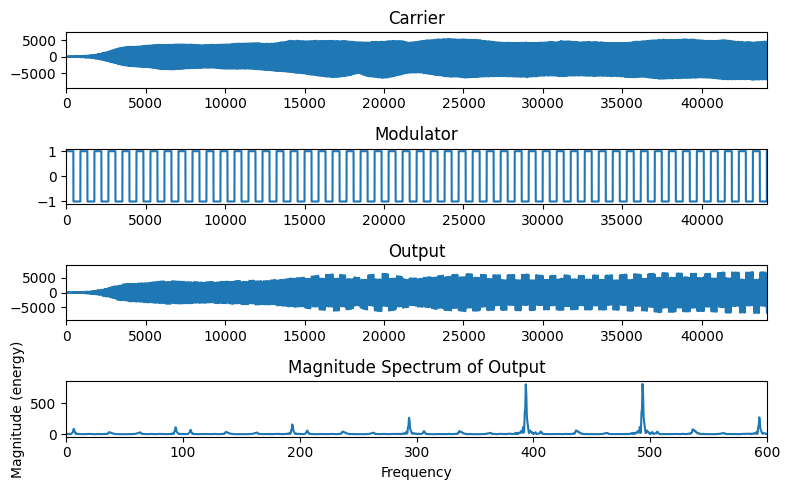

In [284]:
(fs, flute) = read("../audio/flute-A4.wav")
flute_sqr = amp_mod(flute, fs, mod_freq = 50, mod_index=1, wav_shape='sqr', polarity=True)
Audio(flute_sqr, rate=fs)


b) Apply amplitude modulation with a sine wave to a 200 Hz sine wave with an arbitrary modulator frequency. Plot the magnitude spectrum.

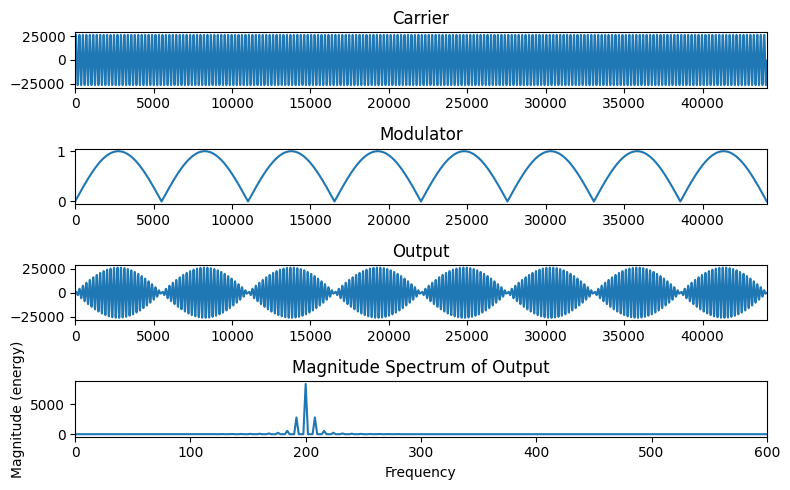

In [285]:
(fs, sin_200) = read("../audio/sine-200.wav")
sin_amp = amp_mod(sin_200, fs, mod_freq = 4, mod_index=1, wav_shape='sin', polarity=False)
Audio(sin_amp, rate=fs)

c) Apply ring modulation with a sine wave to a 200 Hz sine wave with a modulator frequency such that the output is inharmonic. Plot the magnitude spectrum.

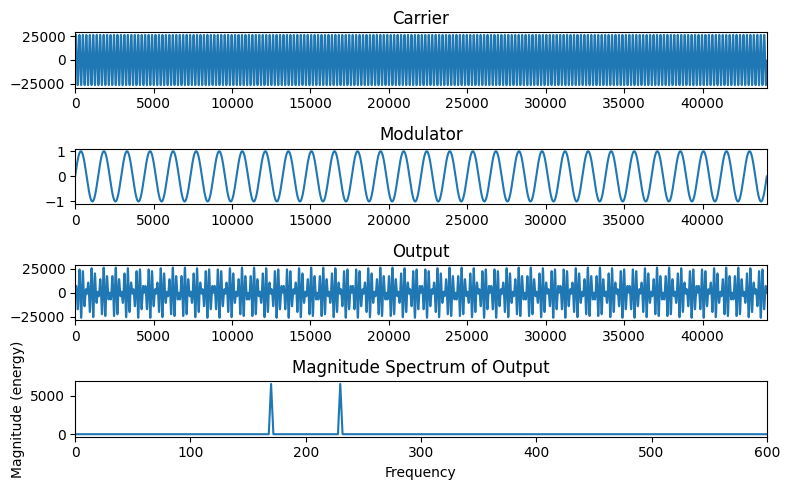

In [286]:
(fs, sin_200) = read("../audio/sine-200.wav")
sin_ring = amp_mod(sin_200, fs, mod_freq = 30, mod_index=1, wav_shape='sin', polarity=True)
Audio(sin_ring, rate=fs)

d) Apply ring modulation with a sine wave to a 200 Hz sine wave with a modulator frequency such that the output only seems to have 1 frequency component. Plot the magnitude spectrum.

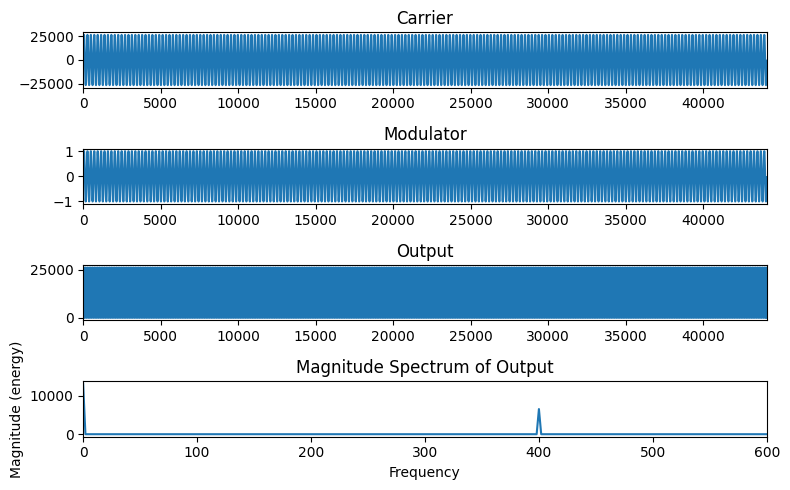

In [287]:
(fs, sin_200) = read("../audio/sine-200.wav")
sin_one = amp_mod(sin_200, fs, mod_freq = 200, mod_index=1, wav_shape='sin', polarity=True)
Audio(sin_one, rate=fs)

## 3. Create an FM synthesis function 

1. Create a function called fmSynth() for FM synthesis (or more aptly PM synthesis). Your function should include the following arguments.

* Depth of modulation *or* modulation index (float) 
* Carrier frequency (float)
* Modulator frequency (float)
* time in seconds (float)

Your function should return a np.array with the synthesized sound

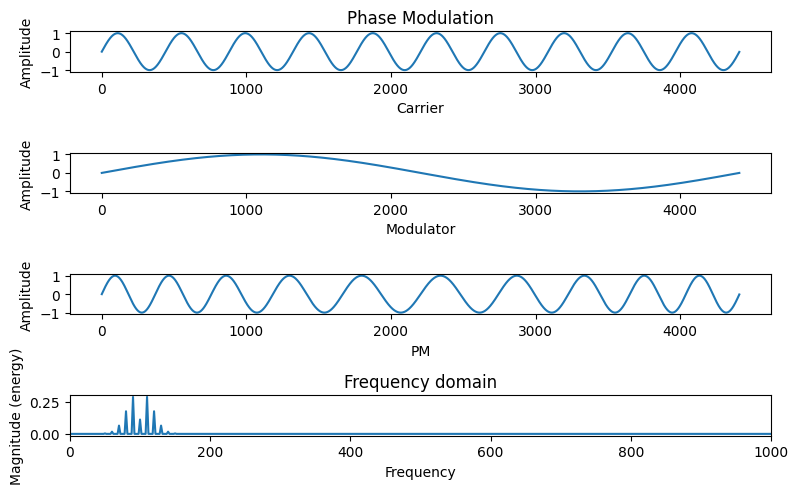

In [288]:
def fm_synth(carrier_freq, mod_freq, mod_index, time, fs=44100, mod_wav_type=None):

    t = np.arange(0, time, 1/fs)

    if mod_wav_type == 'sine' or mod_wav_type == 'sin' or mod_wav_type == None:
        modulator = np.sin(2 * np.pi * mod_freq * t)
    elif mod_wav_type == 'square' or mod_wav_type == 'sqr':
        modulator = signal.square(2 * np.pi * mod_freq * t)
    elif mod_wav_type == 'triangle' or mod_wav_type == 'tri':
        modulator = signal.sawtooth(2 * np.pi * mod_freq * t, 0.5)
    elif mod_wav_type == 'sawtooth' or mod_wav_type == 'saw':
        modulator = signal.sawtooth(2 * np.pi * mod_freq * t)
    else:
        raise ValueError("Invalid mod_wav_type. Must be 'sine','square', 'triangle' or 'sawtooth'.")
    
    out = np.sin((2* np.pi * carrier_freq * t) + (mod_index * modulator))

    ind = int(fs / mod_freq) # for graphing
    carrier = np.sin(2*np.pi * carrier_freq * t) # for graphing

    plt.subplot(4, 1, 1)
    plt.title('Phase Modulation')
    plt.plot(carrier[:ind]) 
    plt.ylabel('Amplitude')
    plt.xlabel('Carrier')
    plt.subplot(4, 1, 2)
    plt.plot(modulator[:ind])
    plt.ylabel('Amplitude')
    plt.xlabel('Modulator')
    plt.subplot(4, 1, 3)
    plt.plot(out[:ind])
    plt.ylabel('Amplitude')
    plt.xlabel('PM')
    plt.subplot(4, 1, 4)
    plt.magnitude_spectrum(out, Fs=44100)
    plt.title("Frequency domain")
    plt.xlim([0,1000])
    plt.tight_layout()

    return out

fm_tone = fm_synth(carrier_freq=100, mod_freq=10, mod_index=2, time=1, fs=44100, mod_wav_type='sine')
Audio(fm_tone, rate=44100)

2) Using your function, try to create the following types of sounds. Try to understand the relation between the modulator and carrier in contributing to harmonic versus inharmonic sounds.

a) Inharmonic   

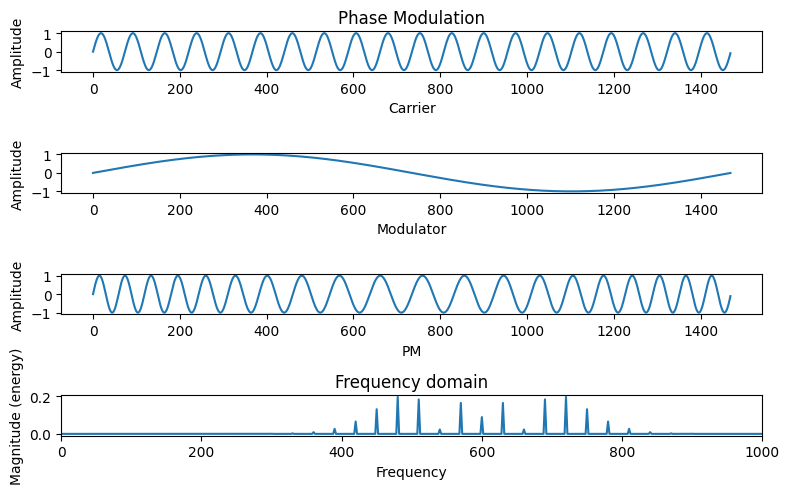

In [289]:
fm_inharm = fm_synth(carrier_freq=600, mod_freq=30, mod_index=5, time=1, fs=44100, mod_wav_type='sine')
Audio(fm_inharm, rate=44100)

 b) harmonic where the carrier is the fundamental  


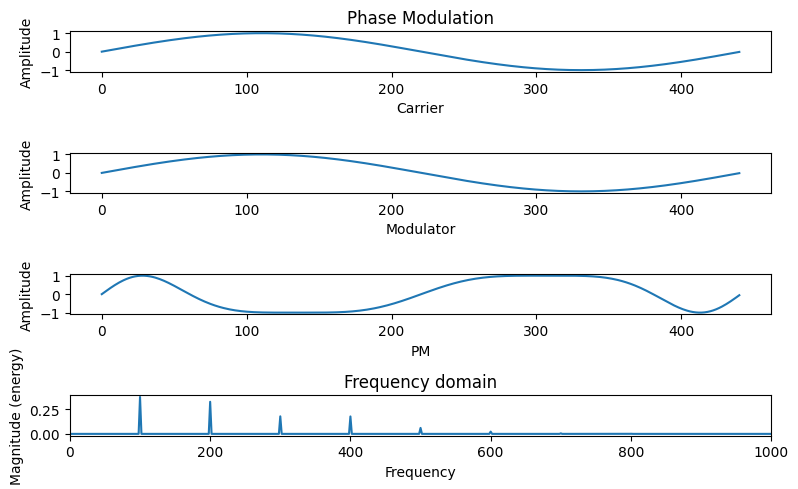

In [290]:
fm_harm = fm_synth(carrier_freq=100, mod_freq=100, mod_index=3, time=1, fs=44100, mod_wav_type='sine')
Audio(fm_harm, rate=44100)

c) harmonic where the carrier is not the fundamental.  

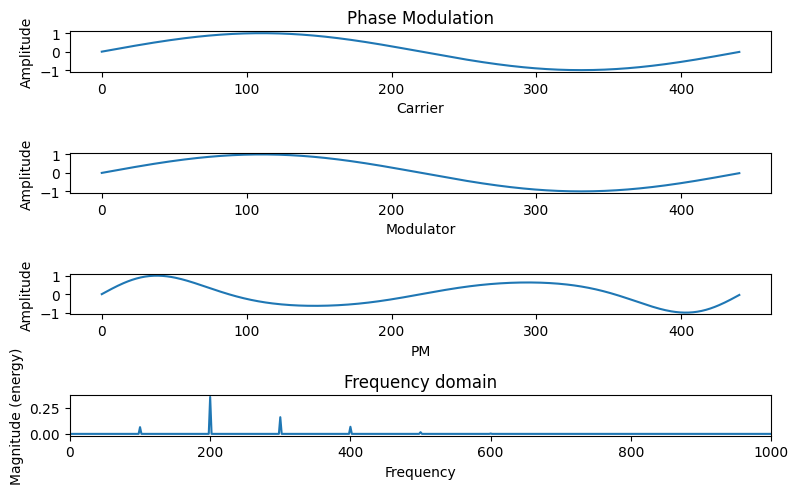

In [291]:
fm_harm_2 = fm_synth(carrier_freq=100, mod_freq=100, mod_index=2, time=1, fs=44100, mod_wav_type='sine')
Audio(fm_harm_2, rate=44100)